<img src="rupixen-Q59HmzK38eQ-unsplash.jpg" alt="Someone is trying to purchase a produce online" width="500"/>

Online shopping decisions rely on how consumers engage with online store content. You work for a new startup company that has just launched a new online shopping website. The marketing team asks you, a new data scientist, to review a dataset of online shoppers' purchasing intentions gathered over the last year. Specifically, the team wants you to generate some insights into customer browsing behaviors in November and December, the busiest months for shoppers. You have decided to identify two groups of customers: those with a low purchase rate and returning customers. After identifying these groups, you want to determine the probability that any of these customers will make a purchase in a new marketing campaign to help gauge potential success for next year's sales.

### Data description:

You are given an `online_shopping_session_data.csv` that contains several columns about each shopping session. Each shopping session corresponded to a single user. 

|Column|Description|
|--------|-----------|
|`SessionID`|unique session ID|
|`Administrative`|number of pages visited related to the customer account|
|`Administrative_Duration`|total amount of time spent (in seconds) on administrative pages|
|`Informational`|number of pages visited related to the website and the company|
|`Informational_Duration`|total amount of time spent (in seconds) on informational pages|
|`ProductRelated`|number of pages visited related to available products|
|`ProductRelated_Duration`|total amount of time spent (in seconds) on product-related pages|
|`BounceRates`|average bounce rate of pages visited by the customer|
|`ExitRates`|average exit rate of pages visited by the customer|
|`PageValues`|average page value of pages visited by the customer|
|`SpecialDay`|closeness of the site visiting time to a specific special day|
|`Weekend`|indicator whether the session is on a weekend|
|`Month`|month of the session date|
|`CustomerType`|customer type|
|`Purchase`|class label whether the customer make a purchase|

In [79]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load and view your data
shopping_data = pd.read_csv("online_shopping_session_data.csv")
shopping_data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month,CustomerType,Purchase
0,1,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
1,2,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,False,Feb,Returning_Customer,0.0
2,3,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
3,4,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,False,Feb,Returning_Customer,0.0
4,5,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,True,Feb,Returning_Customer,0.0


In [80]:

 df = shopping_data[shopping_data['Month'].isin(['Nov', 'Dec'])]
rate = df.groupby('CustomerType')['Purchase'].mean() 
rate

purchase_rates  = rate.to_dict()
purchase_rates 



{'New_Customer': 0.2733516483516483, 'Returning_Customer': 0.1955937667920473}

In [81]:
import numpy as np

# 0) (IMPORTANTE) Subset: solo November y December
nd = shopping_data[shopping_data["Month"].isin(["Nov", "Dec"])]

# 1) Agrupa y cuenta
grouped = nd.groupby(["CustomerType", "Purchase"]).size()

# 2) New_Customer
total_new = grouped.get(("New_Customer", 0), 0) + grouped.get(("New_Customer", 1), 0)
purchases_new = grouped.get(("New_Customer", 1), 0)
rate_new = purchases_new / total_new if total_new else 0

# 3) Returning_Customer
total_ret = grouped.get(("Returning_Customer", 0), 0) + grouped.get(("Returning_Customer", 1), 0)
purchases_ret = grouped.get(("Returning_Customer", 1), 0)
rate_ret = purchases_ret / total_ret if total_ret else 0

# 4) Diccionario final (puedes redondear si te lo piden)
purchase_rates = {
    "Returning_Customer": rate_ret,
    "New_Customer": rate_new
}

purchase_rates


{'Returning_Customer': 0.1955937667920473, 'New_Customer': 0.2733516483516483}


Selection deleted
1
2
3
4
5
6
7
8
9
10
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load and view your data
shopping_data = pd.read_csv("online_shopping_session_data.csv")
shopping_data.head()
shopping_data.columns
Index(['SessionID', 'Administrative', 'Administrative_Duration',
       'Informational', 'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
       'SpecialDay', 'Weekend', 'Month', 'CustomerType', 'Purchase'],
      dtype='object')

In [82]:
shopping_data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month,CustomerType,Purchase
0,1,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
1,2,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,False,Feb,Returning_Customer,0.0
2,3,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
3,4,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,False,Feb,Returning_Customer,0.0
4,5,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,True,Feb,Returning_Customer,0.0


In [83]:
#shopping_data.groupby(['Informational','ProductRelated','Administrative']).sum(['ProductRelated_Duration','Informational_Duration','Administrative_Duration'])
df[df['CustomerType'] == 'Returning_Customer']
durations = df[['ProductRelated_Duration','Informational_Duration','Administrative_Duration']].corr()
durations

durations.values[np.diag_indices_from(durations)] = np.nan

max = durations.max().max()
pair = durations.stack().idxmax()

top_correlation = {
    "pair": pair,
    "correlation": max
}
top_correlation



{'pair': ('ProductRelated_Duration', 'Administrative_Duration'),
 'correlation': 0.3898546003206953}

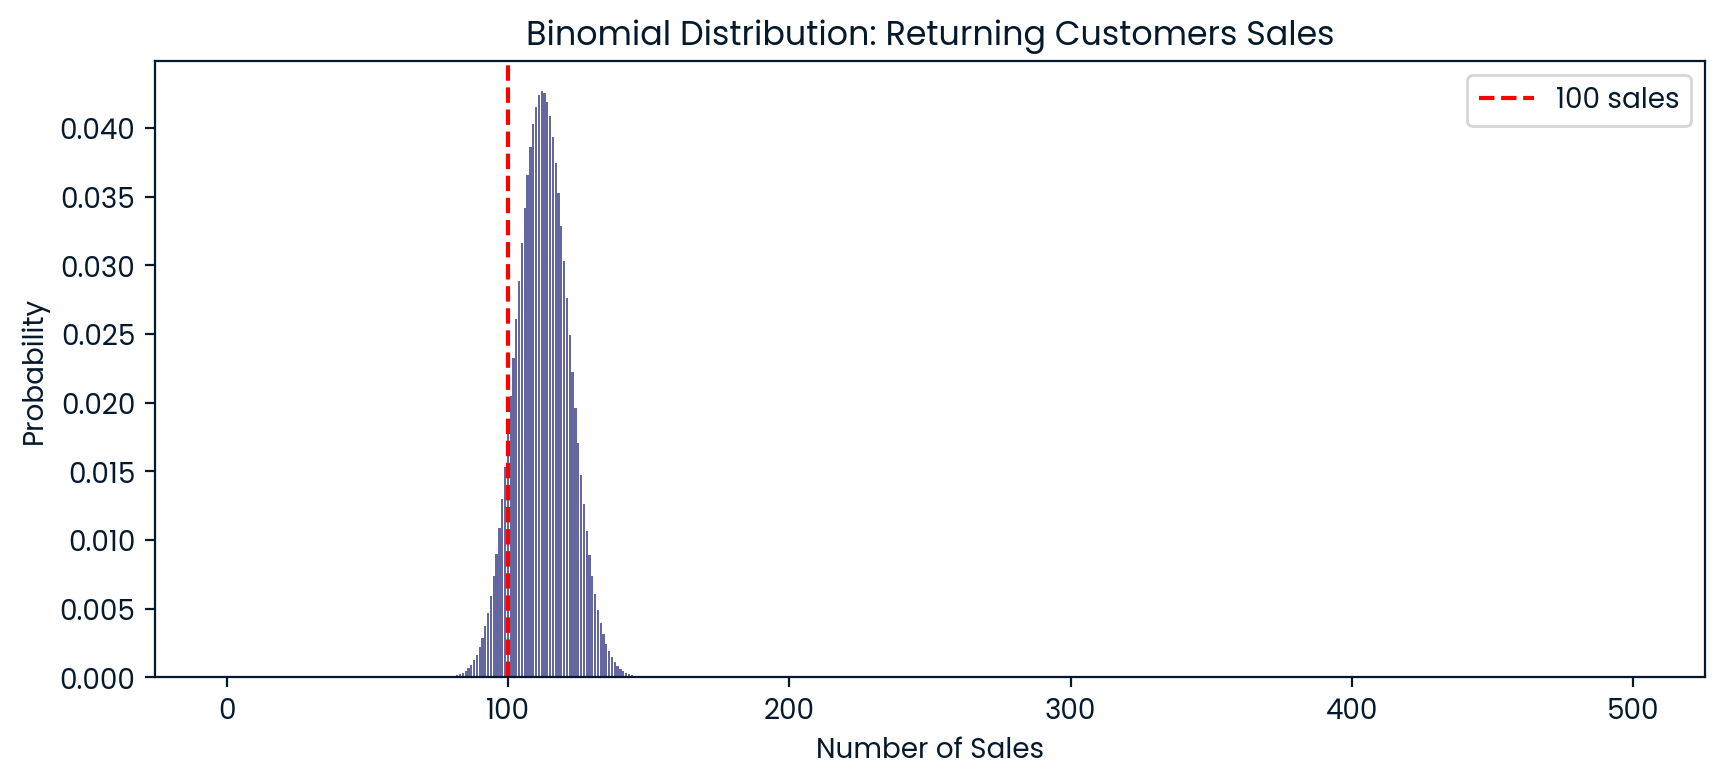

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# 1) Filtrar Returning Customers en Nov y Dec
df = shopping_data[
    (shopping_data["CustomerType"] == "Returning_Customer") &
    (shopping_data["Month"].isin(["Nov", "Dec"]))
]

# 2) Tasa base de compra (mean de variable binaria)
base_rate = df["Purchase"].mean()

# 3) Nueva tasa con aumento del 15% (relativo)
p = base_rate * 1.15

# 4) Parámetros del experimento binomial
n = 500          # sesiones
k = 100          # al menos 100 compras

# 5) Probabilidad de lograr al menos 100 ventas
prob_at_least_100_sales = 1 - binom.cdf(k - 1, n, p)

prob_at_least_100_sales

x = np.arange(0, n + 1)
y = binom.pmf(x, n, p)

plt.figure(figsize=(10, 4))
plt.bar(x, y)
plt.axvline(100, color='red', linestyle='--', label='100 sales')
plt.title("Binomial Distribution: Returning Customers Sales")
plt.xlabel("Number of Sales")
plt.ylabel("Probability")
plt.legend()
plt.show()

